# 📥 Notebook 01 — Data Ingestion

**Project:** Nigeria Disease Surveillance Dashboard  
**Purpose:** Extract raw data from all sources and save to `data/raw/`.  
No cleaning happens here — this notebook is extraction only.  

**Sources covered:**
- NCDC Nigeria PDF Situation Reports
- WHO AFRO CSV/Excel files
- NASA POWER Rainfall API
- HDX Nigeria Health Facilities CSV
- NBS / WorldPop Population data
- GRID3 Nigeria State Shapefiles

**Output:** Raw files saved to `data/raw/`

---
> **Rule:** Never modify files in `data/raw/`. They are the ground truth.  
> All cleaning happens in Notebook 02.

## 1. Environment Setup

In [1]:
import os
import sys
import time
import json
import logging
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np

# Add the project root to sys.path so we can import src modules
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import project utilities
from src.utils.config import Paths, settings, Diseases
from src.utils.logger import get_logger, set_log_level
from src.utils.state_maps import CANONICAL_STATES, STATE_CENTROIDS

# Set log level for notebook output
set_log_level('INFO')
logger = get_logger('notebook_01')

# Ensure all data directories exist
Paths.ensure_all()

print('✅ Environment ready')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   Raw data     : {Paths.raw}')
print(f'   Shapefiles   : {Paths.shapefiles}')
print(f'   Diseases     : {Diseases.all}')

✅ Environment ready
   Project root : C:\Users\Hp\Documents\nigeria-disease-surveillance
   Raw data     : C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw
   Shapefiles   : C:\Users\Hp\Documents\nigeria-disease-surveillance\data\shapefiles
   Diseases     : ['Cholera', 'Lassa Fever', 'Mpox', 'Meningitis', 'Yellow Fever']


## 2. NCDC PDF Extraction

The NCDC publishes weekly Situation Reports as PDFs.  
Each PDF contains state-level case count tables for one or more diseases.

**Before running this cell:**
1. Download PDFs from [ncdc.gov.ng/diseases/sitreps](https://ncdc.gov.ng/diseases/sitreps)
2. Place them in the correct folder:
   - Cholera → `data/raw/ncdc_pdfs/cholera/`
   - Lassa Fever → `data/raw/ncdc_pdfs/lassa_fever/`
   - Mpox → `data/raw/ncdc_pdfs/mpox/`
   - Meningitis → `data/raw/ncdc_pdfs/meningitis/`
   - Yellow Fever → `data/raw/ncdc_pdfs/yellow_fever/`

> **Expect messy output.** NCDC PDFs have inconsistent formatting  
> across years. That messiness is handled in Notebook 02.

In [2]:
from src.etl.extract import extract_ncdc_pdfs

raw_ncdc = {}

for disease_name, folder_key in Diseases.pdf_folder_map.items():
    folder = Paths.raw / 'ncdc_pdfs' / folder_key
    print(f'\n📂 Extracting {disease_name}...')
    print(f'   Looking in: {folder}')

    df = extract_ncdc_pdfs(folder, disease_name)

    if df.empty:
        print(f'   ⚠️  No PDFs found — place NCDC sitreps in {folder}')
    else:
        raw_ncdc[disease_name] = df
        print(f'   ✅ {len(df):,} rows extracted')
        print(f'   Columns: {list(df.columns)}')

print(f'\n📊 Extraction summary: {len(raw_ncdc)}/{len(Diseases.all)} diseases extracted')


📂 Extracting Cholera...
   Looking in: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\cholera
2026-06-09 16:21:28 | INFO     | src.etl.extract | NCDC Cholera: loaded 1089 rows from cache
   ✅ 1,089 rows extracted
   Columns: ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']

📂 Extracting Lassa Fever...
   Looking in: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\lassa_fever
2026-06-09 16:21:28 | INFO     | src.etl.extract | NCDC Lassa Fever: loaded 4040 rows from cache
   ✅ 4,040 rows extracted
   Columns: ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type', '_note']

📂 Extracting Mpox...
   Looking in: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\mpox
2026-06-09 16:21:28 | INFO     | src.etl.extract | NCDC Mpox: loaded 695 rows from cache
   ✅ 695 rows extrac

### 2.1 Inspect raw NCDC output

Take a close look at what came out of the PDFs. Expect None values, garbled columns, and merged cells.

In [3]:
def inspect_df(df: pd.DataFrame, name: str, n_rows: int = 3) -> None:
    """Print a structured summary of any DataFrame."""
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {name}')
    print(sep)
    print(f'  Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Columns : {list(df.columns)}')
    nulls = df.isnull().sum()
    if nulls.any():
        print('  Nulls   :')
        for col, n in nulls[nulls > 0].items():
            print(f'            {col:<35} {n:>6,}')
    print(f'  Sample ({n_rows} rows):')
    display(df.head(n_rows))

for disease, df in raw_ncdc.items():
    inspect_df(df, f'NCDC — {disease}')


  NCDC — Cholera
  Shape   : 1,089 rows × 10 columns
  Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
  Nulls   :
            state                                   21
            cfr_pct                              1,066
  Sample (3 rows):


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Borno,Cholera,52,2022,6,0,0,NaN,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
1,Yobe,Cholera,52,2022,0,0,0,NaN,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
2,Katsina,Cholera,52,2022,1,0,0,NaN,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week



  NCDC — Lassa Fever
  Shape   : 4,040 rows × 11 columns
  Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type', '_note']
  Nulls   :
            cfr_pct                              4,037
            _note                                4,037
  Sample (3 rows):


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type,_note
0,Edo,Lassa Fever,1,2023,38,3,0,NaN,1b40aecdc7a9100797389299b2519a38.pdf,current_week,NaN
1,Bauchi,Lassa Fever,1,2023,7,3,2,NaN,1b40aecdc7a9100797389299b2519a38.pdf,current_week,NaN
2,Taraba,Lassa Fever,1,2023,2,0,0,NaN,1b40aecdc7a9100797389299b2519a38.pdf,current_week,NaN



  NCDC — Mpox
  Shape   : 695 rows × 10 columns
  Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
  Nulls   :
            cfr_pct                                695
  Sample (3 rows):


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Akwa Ibom,Mpox,36,2022,0,2,0,NaN,An Update of Monkeypox Outbreak in Nigeria_010...,current_week
1,Anambra,Mpox,36,2022,0,2,0,NaN,An Update of Monkeypox Outbreak in Nigeria_010...,current_week
2,Bayelsa,Mpox,36,2022,0,1,0,NaN,An Update of Monkeypox Outbreak in Nigeria_010...,current_week



  NCDC — Meningitis
  Shape   : 201 rows × 10 columns
  Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
  Nulls   :
            cfr_pct                                194
  Sample (3 rows):


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Jigawa,Meningitis,29,2023,3,0,0,0.0,519e5ccfcc5d808281ba57e9d4597352.pdf,current_week_highlights
1,Gombe,Meningitis,29,2023,2,0,0,0.0,519e5ccfcc5d808281ba57e9d4597352.pdf,current_week_highlights
2,Bayelsa,Meningitis,47,2023,0,0,0,NaN,An Update of Meningitis Outbreak in Nigeria_16...,current_week



  NCDC — Yellow Fever
  Shape   : 772 rows × 10 columns
  Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
  Nulls   :
            cfr_pct                                772
  Sample (3 rows):


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Akwa Ibom,Yellow Fever,18,2023,1,0,0,NaN,1f1c39c3c68eacf284bddcd5d8d7f5eb.pdf,current_highlights
1,Anambra,Yellow Fever,18,2023,5,0,0,NaN,1f1c39c3c68eacf284bddcd5d8d7f5eb.pdf,current_highlights
2,Bauchi,Yellow Fever,18,2023,38,0,0,NaN,1f1c39c3c68eacf284bddcd5d8d7f5eb.pdf,current_highlights


## 3. WHO AFRO Data

WHO AFRO data serves as a cross-validation source for NCDC figures.  

**Download from:** [afro.who.int](https://afro.who.int/health-topics)  
**Save to:** `data/raw/who/`  
**Supported formats:** `.csv`, `.xlsx`

In [4]:
from src.etl.extract import extract_who_data

print('📂 Loading WHO AFRO data...')
raw_who = extract_who_data()

if raw_who.empty:
    print('⚠️  No WHO data found.')
    print('   Download from afro.who.int and place in data/raw/who/')
else:
    inspect_df(raw_who, 'WHO AFRO')

📂 Loading WHO AFRO data...
2026-06-09 16:23:37 | INFO     | src.etl.extract | WHO: loaded 45 rows from cache

  WHO AFRO
  Shape   : 45 rows × 5 columns
  Columns : ['year', 'disease', 'reported_cases', 'reported_deaths', '_source_file']
  Sample (3 rows):


,year,disease,reported_cases,reported_deaths,_source_file
0,1970,Cholera,0,4,WHO_GHO_API
1,1971,Cholera,0,2945,WHO_GHO_API
2,1972,Cholera,0,96,WHO_GHO_API


## 4. NASA POWER Rainfall API

We query the NASA POWER API for monthly precipitation at each state's centroid.  
This data is used to correlate rainfall with cholera and meningitis seasonality.

**No API key required.** Rate limit: ~30 requests/minute.  
The fetch loop adds a 2-second delay between states.

> ⏱️ **Expected runtime: 2–3 minutes** for all 37 states.

In [5]:
from src.etl.extract import extract_nasa_rainfall

print('🌧️  Fetching NASA POWER rainfall data...')
print(f'   States to fetch: {len(STATE_CENTROIDS)}')
print('   This will take ~3 minutes.\n')

raw_rainfall = extract_nasa_rainfall(
    start_year     = 2015,
    end_year       = 2024,
    force_download = False,   # Use cached file if available
)

if raw_rainfall.empty:
    print('⚠️  No rainfall data retrieved (check network access)')
else:
    inspect_df(raw_rainfall, 'NASA POWER Rainfall')
    print(f'\n   Date range: {raw_rainfall["year"].min()}–{raw_rainfall["year"].max()}')
    print(f'   States    : {raw_rainfall["state"].nunique()}/37')
    print(f'   Avg mm/mo : {raw_rainfall["rainfall_mm"].mean():.1f}')

🌧️  Fetching NASA POWER rainfall data...
   States to fetch: 37
   This will take ~3 minutes.

2026-06-09 16:24:13 | INFO     | src.etl.extract | Rainfall: loaded 4440 rows from cache

  NASA POWER Rainfall
  Shape   : 4,440 rows × 6 columns
  Columns : ['state', 'year', 'month', 'rainfall_mm', 'latitude', 'longitude']
  Sample (3 rows):


,state,year,month,rainfall_mm,latitude,longitude
0,Abia,2015,1,0.07,5.4527,7.5248
1,Abia,2015,2,1.17,5.4527,7.5248
2,Abia,2015,3,3.86,5.4527,7.5248



   Date range: 2015–2024
   States    : 37/37
   Avg mm/mo : 4.1


## 5. Health Facilities (HDX)

Facility locations are used for the accessibility gap analysis —  
identifying states with high disease burden but few facilities.

**Download from:** [data.humdata.org](https://data.humdata.org)  
**Search:** 'Nigeria health facilities'  
**Save to:** `data/raw/health_facilities.csv`

In [6]:
from src.etl.extract import extract_health_facilities

print('🏥 Loading health facilities...')
raw_facilities = extract_health_facilities()

if raw_facilities.empty:
    print('⚠️  health_facilities.csv not found.')
    print('   Download from data.humdata.org (search Nigeria health facilities)')
else:
    inspect_df(raw_facilities, 'Health Facilities')
    type_col = next(
        (c for c in raw_facilities.columns
         if 'type' in c.lower() or 'category' in c.lower()), None
    )
    if type_col:
        print(f'\n   Facility types (column: {type_col}):')
        for val, count in raw_facilities[type_col].value_counts().head(10).items():
            print(f'     {val:<40} {count:>6,}')

🏥 Loading health facilities...

  Health Facilities
  Shape   : 46,146 rows × 25 columns
  Columns : ['X', 'Y', 'FID', 'globalid', 'uniq_id', 'timestamp', 'editor', 'latitude', 'longitude', 'wardname', 'wardcode', 'lganame', 'lgacode', 'statename', 'statecode', 'updated_on', 'accessblty', 'func_stats', 'category', 'ownership', 'type', 'source', 'alt_name', 'prmry_name', '_source_file']
  Nulls   :
            statecode                            1,126
            updated_on                             223
  Sample (3 rows):


,X,Y,FID,globalid,uniq_id,timestamp,editor,latitude,longitude,wardname,...,updated_on,accessblty,func_stats,category,ownership,type,source,alt_name,prmry_name,_source_file
0,13.148320,11.822320,1,af719462-abfd-4f47-9dc3-0987164e75ac,1,2020/07/04 00:00:00+00,tosin.williams,11.822320,13.148320,Maisandari,...,2019/03/01 00:00:00+00,,Unknown,Primary Health Center,Private,Primary,eHA Polio,Nursing Home,G R A Nursing Home,health_facilities.csv
1,13.147176,11.821615,2,a29b0328-d844-4358-b0ab-2e120b8fb30f,2,2020/07/04 00:00:00+00,mokobia.chidinma,11.821615,13.147176,Maisandari,...,2019/03/01 00:00:00+00,Unknown,Functional,Primary Health Center,National Primary Healthcare Development Agency,Primary,Measles Campaign,Nursing Home,Gishili Health Center,health_facilities.csv
2,12.816284,10.707092,3,b685b769-5c83-4f83-a182-00e7e1b777d8,3,2020/07/04 00:00:00+00,mokobia.chidinma,10.707092,12.816284,Ngohi,...,2019/03/01 00:00:00+00,,Partially Functional,Primary Health Center,State Primary Healthcare Development Agency,Primary,eHA Polio,,Lehobi Primary Health Care,health_facilities.csv



   Facility types (column: category):
     Primary Health Center                    28,031
     Dispensary                                8,626
     Maternity Home                            4,423
     Private Non Profit                        1,179
     Medical Center                              956
     Specialist Hospital                         673
     General Hospital                            637
     Comprehensive Health Center                 458
     Educational Clinic                          249
     Laboratory                                  234


## 6. Population Data (NBS / WorldPop)

State population estimates are used to calculate incidence rates per 100,000.

**Download from:** [nigerianstat.gov.ng](https://nigerianstat.gov.ng) or  
[worldpop.org](https://worldpop.org)  
**Save to:** `data/raw/nigeria_population.xlsx` or `.csv`

In [7]:
from src.etl.extract import extract_population

print('👥 Loading population data...')
raw_population = extract_population()

if raw_population.empty:
    print('⚠️  Population file not found.')
    print('   Download from nigerianstat.gov.ng')
else:
    inspect_df(raw_population, 'Population Data')

👥 Loading population data...

  Population Data
  Shape   : 1,533 rows × 10 columns
  Columns : ['State code', 'State', 'LGA code', 'LGA', 'Notes', 'Population Data Source', 'Female', 'Male', 'Total', '_source_file']
  Nulls   :
            State code                              26
            Notes                                  774
  Sample (3 rows):


,State code,State,LGA code,LGA,Notes,Population Data Source,Female,Male,Total,_source_file
0,AB,Abia,1001,Aba North,NaN,WorldPop and National Population Commission of...,139786.189633,138827.372076,278613.561709,nigeria_population.xlsx
1,AB,Abia,1001,Aba North,Population Outside Settlements,WorldPop and National Population Commission of...,1.000000,1.000000,2.000000,nigeria_population.xlsx
2,AB,Abia,1002,Aba South,NaN,WorldPop and National Population Commission of...,137522.386930,146879.114223,284401.501153,nigeria_population.xlsx


## 7. Geospatial Shapefiles (GRID3)

State boundary polygons are used for choropleth maps.

**Download from:** [grid3.org](https://grid3.org) or [gadm.org/country/NGA](https://gadm.org/country/NGA)  
**Save to:** `data/shapefiles/nigeria_states.shp` (and associated files)

🗺️  Loading shapefiles...
2026-06-09 16:24:41 | INFO     | src.etl.extract | Shapefiles: loaded 37 state features from grid3_nga_boundary_vaccstates.shp (CRS=EPSG:4326)

  ✅ states: 37 features, CRS=EPSG:4326
     Columns: ['globalid', 'uniq_id', 'timestamp', 'editor', 'statename', 'statecode', 'capcity', 'source', 'geozone', 'geometry']


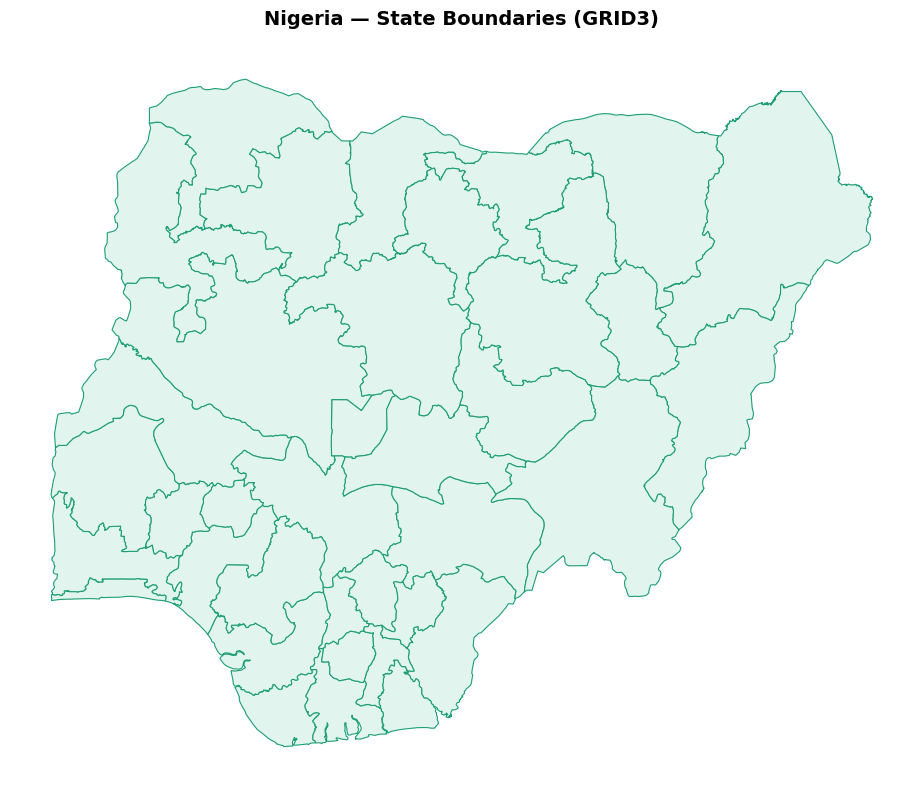


   ✅ Map saved to data/raw/nigeria_states_map.png


In [8]:
from src.etl.extract import extract_shapefiles
import matplotlib.pyplot as plt

print('🗺️  Loading shapefiles...')
shapefiles = extract_shapefiles()

if not shapefiles:
    print('⚠️  No shapefiles found in data/shapefiles/')
    print('   Download from grid3.org')
else:
    for name, gdf in shapefiles.items():
        print(f'\n  ✅ {name}: {len(gdf)} features, CRS={gdf.crs}')
        print(f'     Columns: {list(gdf.columns)}')

    # Plot the state boundaries — your first map!
    if 'states' in shapefiles:
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        shapefiles['states'].plot(
            ax          = ax,
            color       = '#E1F5EE',
            edgecolor   = '#1D9E75',
            linewidth   = 0.8,
        )
        ax.set_title(
            'Nigeria — State Boundaries (GRID3)',
            fontsize=14, fontweight='bold', pad=15
        )
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.axis('off')
        plt.tight_layout()
        # Save as PNG for the README
        fig.savefig(Paths.raw / 'nigeria_states_map.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print('\n   ✅ Map saved to data/raw/nigeria_states_map.png')

## 8. Ingestion Summary

In [9]:
print('='*55)
print('  NOTEBOOK 01 — INGESTION SUMMARY')
print('='*55)
print(f'  Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print()

# Summarise what was loaded
sources = {
    'NCDC diseases extracted' : f'{len(raw_ncdc)}/{len(Diseases.all)}',
    'WHO AFRO rows'           : f'{len(raw_who):,}' if not raw_who.empty else 'NOT LOADED',
    'Rainfall records'        : f'{len(raw_rainfall):,}' if not raw_rainfall.empty else 'NOT LOADED',
    'Health facilities'       : f'{len(raw_facilities):,}' if not raw_facilities.empty else 'NOT LOADED',
    'Population rows'         : f'{len(raw_population):,}' if not raw_population.empty else 'NOT LOADED',
    'Shapefiles loaded'       : f'{len(shapefiles)} ({list(shapefiles.keys())})',
}

for label, value in sources.items():
    status = '✅' if 'NOT' not in str(value) else '⚠️ '
    print(f'  {status}  {label:<30} {value}')

# Count raw files saved
saved = list(Paths.raw.glob('*.csv'))
print(f'\n  Raw CSV files saved to data/raw/ : {len(saved)}')
for f in saved:
    print(f'    - {f.name} ({f.stat().st_size / 1024:.1f} KB)')

print()
print('  ➡️  Next step: Run Notebook 02 — Data Cleaning')
print('='*55)

  NOTEBOOK 01 — INGESTION SUMMARY
  Timestamp: 2026-06-09 16:24

  ✅  NCDC diseases extracted        5/5
  ✅  WHO AFRO rows                  45
  ✅  Rainfall records               4,440
  ✅  Health facilities              46,146
  ✅  Population rows                1,533
  ✅  Shapefiles loaded              1 (['states'])

  Raw CSV files saved to data/raw/ : 10
    - health_facilities.csv (14205.1 KB)
    - health_facilities_raw.csv (15239.4 KB)
    - ncdc_cholera_raw.csv (105.1 KB)
    - ncdc_lassa_fever_raw.csv (415.2 KB)
    - ncdc_meningitis_raw.csv (20.2 KB)
    - ncdc_mpox_raw.csv (65.5 KB)
    - ncdc_yellow_fever_raw.csv (80.1 KB)
    - population_raw.csv (230.6 KB)
    - rainfall_raw.csv (145.3 KB)
    - who_raw.csv (1.5 KB)

  ➡️  Next step: Run Notebook 02 — Data Cleaning
